In [68]:
import torch

ckpt = torch.load(checkpoint_path, map_location="cpu")
state = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt

def dump_dict(d, prefix=""):
    for k, v in d.items():
        name = f"{prefix}{k}"
        if isinstance(v, dict):
            print(f"{name}/")
            dump_dict(v, prefix=name + ".")
        elif torch.is_tensor(v):
            print(f"{name:60s} | shape={tuple(v.shape)} | dtype={v.dtype}")
        else:
            print(f"{name:60s} | type={type(v)}")

dump_dict(state["model"] if isinstance(state, dict) and "model" in state else state)

nets/
nets.policy.core.rnn_cell.gleak                              | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.vleak                              | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.cm                                 | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.sigma                              | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.mu                                 | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.w                                  | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.erev                               | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_sigma                      | shape=(19, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_mu                         | shape=(19, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_w                          | shape=(19, 64) | dtype=torch.float32
net

Total keys found: 130


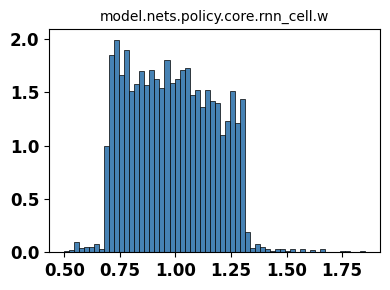

Sparsity (w*mask): 88.11%


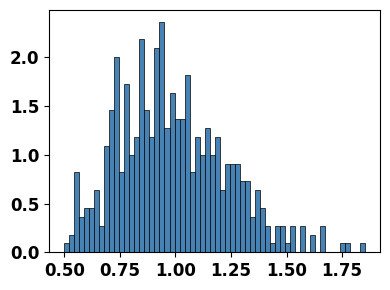

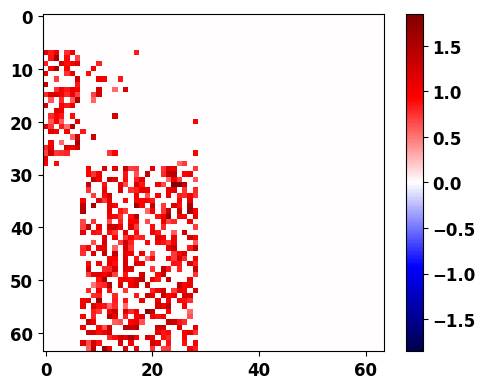

Sparsity (w*mask*erev): 88.11%


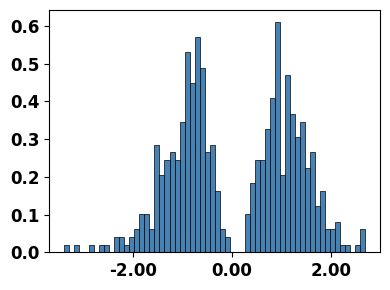

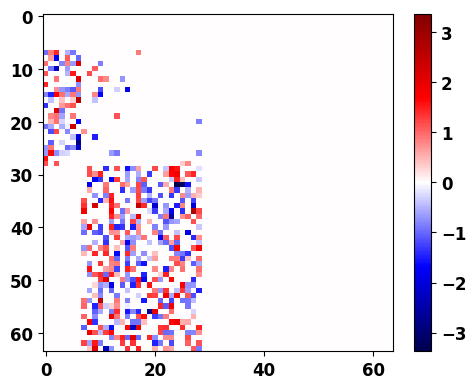

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import numpy as np
import torch.nn.functional as F


def flatten_dict(d, prefix=""):
    flat = {}
    for k, v in d.items():
        name = f"{prefix}{k}"
        if isinstance(v, dict):
            flat.update(flatten_dict(v, prefix=name + "."))
        else:
            flat[name] = v
    return flat


def find_key_endswith(flat_dict, suffix):
    for k in flat_dict.keys():
        if k.endswith(suffix):
            return k
    return None

def symmetrize_midpoint(x):
    min_val = torch.min(x)
    max_val = torch.max(x)
    midpoint = (min_val + max_val) / 2.0
    return x - midpoint

def clipping_percentile(x, percentile=99.0):
    q = torch.quantile(torch.abs(x), percentile / 100.0)
    x_clipped = torch.clamp(x, -q, q)
    return x_clipped

def plot_params(
    checkpoint_path: str,
    include_keywords=None,
    max_plots: int = 12,
    bins: int = 60,
    tick_fontsize: int = 12,
    flag: bool = False,
    softplus: bool = False,
):

    def _apply_sp(x):
        return F.softplus(x) if softplus else x

    # ------------------------------------------------------------------
    # 1. モデルロード
    # ------------------------------------------------------------------
    state = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state and isinstance(state["state_dict"], dict):
        state = state["state_dict"]

    # ------------------------------------------------------------------
    # 2. 平坦化
    # ------------------------------------------------------------------
    flat = flatten_dict(state)
    print(f"Total keys found: {len(flat)}")

    # ------------------------------------------------------------------
    # 3. フィルタと収集
    # ------------------------------------------------------------------
    def use_param(name):
        if not include_keywords:
            return True
        return any(k in name for k in include_keywords)

    items = [
        (n, p) for n, p in flat.items()
        if torch.is_tensor(p) and torch.is_floating_point(p) and use_param(n)
    ]

    if not items:
        print("警告: 該当するパラメータが見つかりませんでした。")
        return

    # ------------------------------------------------------------------
    # 4. ヒストグラム（PART 1）
    # ------------------------------------------------------------------
    items = items[:max_plots]
    n = len(items)
    cols = min(3, n)
    rows = math.ceil(n / cols)

    plt.figure(figsize=(4 * cols, 3 * rows))
    for i, (name, tensor) in enumerate(items, 1):
        tensor = _apply_sp(tensor)  # ← softplus 適用
        t_np = tensor.detach().cpu().flatten().numpy()

        ax = plt.subplot(rows, cols, i)
        ax.hist(
            t_np,
            bins=bins,
            density=True,
            color="steelblue",
            edgecolor="black",
            linewidth=0.5,
            alpha=1.0,
        )
        ax.set_title(name, fontsize=10)
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # 5. Sparsity: w * mask（PART 2）
    # ------------------------------------------------------------------
    w_key = find_key_endswith(flat, "rnn_cell.w")
    mask_key = find_key_endswith(flat, "rnn_cell.sparsity_mask")
    erev_key = find_key_endswith(flat, "rnn_cell.erev")

    if w_key and mask_key and flag:
        w = _apply_sp(flat[w_key])      # ← softplus 適用
        mask = flat[mask_key]
        effective_weights = w * mask

        total_params = effective_weights.numel()
        zero_params = (effective_weights == 0).sum().item()
        sparsity_percent = (zero_params / total_params) * 100
        print(f"Sparsity (w*mask): {sparsity_percent:.2f}%")

        # --- 非ゼロ成分ヒストグラム ---
        nz = effective_weights[effective_weights != 0]
        plt.figure(figsize=(4, 3))
        ax = plt.gca()
        if nz.numel() > 0:
            ax.hist(
                nz.detach().cpu().flatten().numpy(),
                bins=bins,
                density=True,
                color="steelblue",
                edgecolor="black",
                linewidth=0.5,
                alpha=1.0,
            )
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        plt.tight_layout()
        plt.show()

        # --- ヒートマップ ---
        plt.figure(figsize=(5, 4))
        ax = plt.gca()
        w_mat = effective_weights.detach().cpu().numpy()
        abs_max = np.abs(w_mat).max() if w_mat.size > 0 else 1.0
        im = ax.imshow(
            w_mat,
            cmap="seismic",
            vmin=-abs_max,
            vmax=abs_max,
            interpolation="nearest",
            aspect="auto",
        )
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

        cbar = plt.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=tick_fontsize)
        for label in cbar.ax.get_yticklabels():
            label.set_fontweight("bold")

        plt.tight_layout()
        plt.show()
    else:
        print("Sparsity mask or weights not found.")

    # ------------------------------------------------------------------
    # 6. 対称化
    # ------------------------------------------------------------------
    

    # ------------------------------------------------------------------
    # 6. Sparsity: w * mask * erev（PART 3）
    # ------------------------------------------------------------------
    if w_key and mask_key and erev_key and flag:
        w = _apply_sp(flat[w_key])      # ← softplus 適用
        mask = flat[mask_key]
        erev = flat[erev_key]
        effective_weights = w * mask * erev

        total_params = effective_weights.numel()
        zero_params = (effective_weights == 0).sum().item()
        sparsity_percent = (zero_params / total_params) * 100
        print(f"Sparsity (w*mask*erev): {sparsity_percent:.2f}%")

        nz = effective_weights[effective_weights != 0]
        plt.figure(figsize=(4, 3))
        ax = plt.gca()
        if nz.numel() > 0:
            ax.hist(
                nz.detach().cpu().flatten().numpy(),
                bins=bins,
                density=True,
                color="steelblue",
                edgecolor="black",
                linewidth=0.5,
                alpha=1.0,
            )
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(5, 4))
        ax = plt.gca()
        w_mat = effective_weights.detach().cpu().numpy()
        abs_max = np.abs(w_mat).max() if w_mat.size > 0 else 1.0
        im = ax.imshow(
            w_mat,
            cmap="seismic",
            vmin=-abs_max,
            vmax=abs_max,
            interpolation="nearest",
            aspect="auto",
        )
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

        cbar = plt.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=tick_fontsize)
        for label in cbar.ax.get_yticklabels():
            label.set_fontweight("bold")

        plt.tight_layout()
        plt.show()


plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.w"], flag=True, softplus=True)

Loading model from /work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth ...
  [Center Info] Non-zero Min: 0.4996, Max: 1.8527, Midpoint: 1.1762


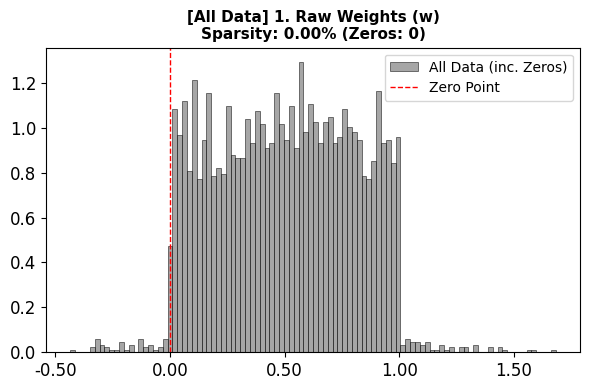

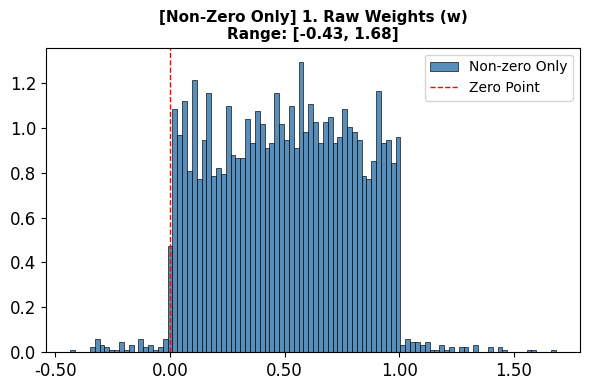

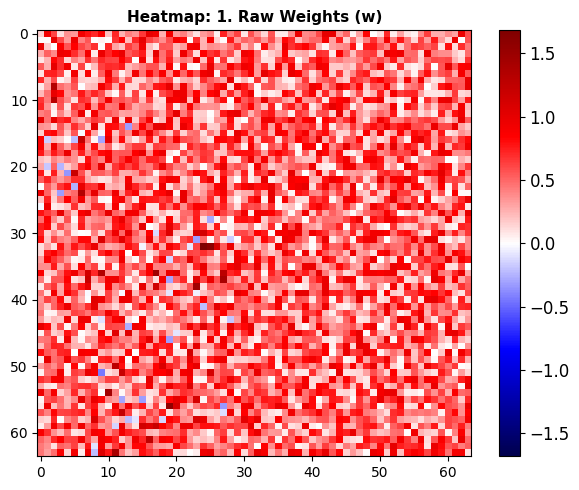

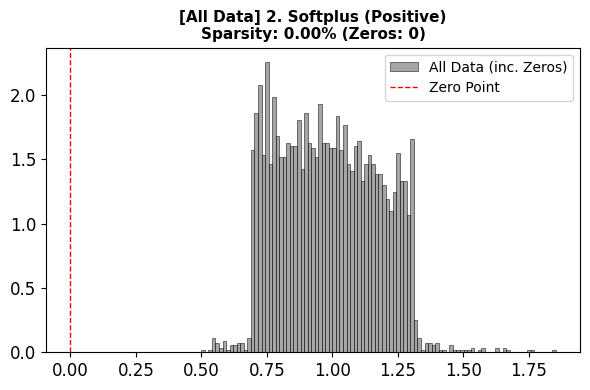

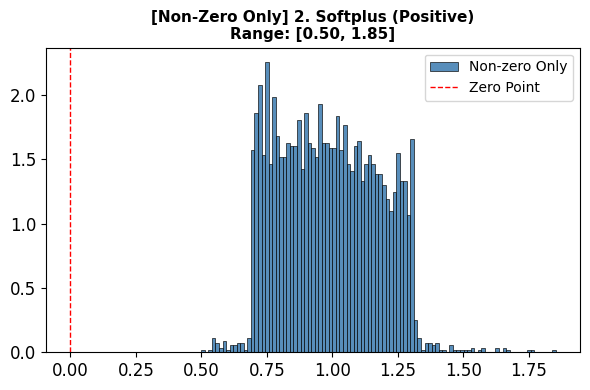

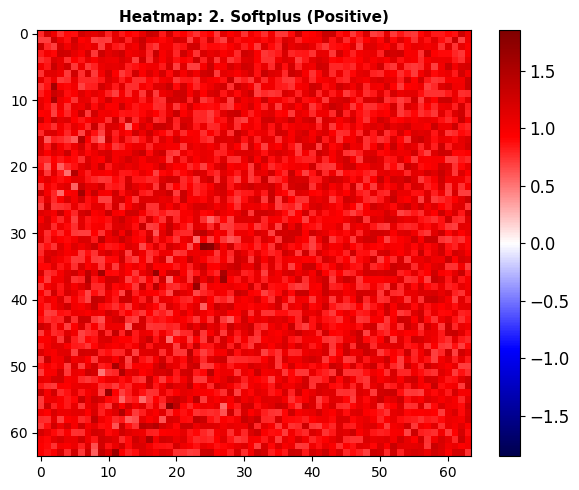

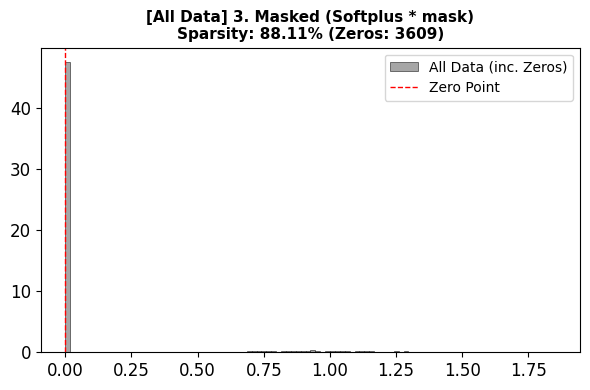

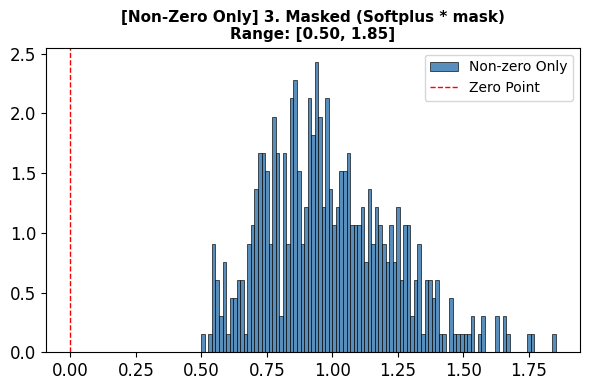

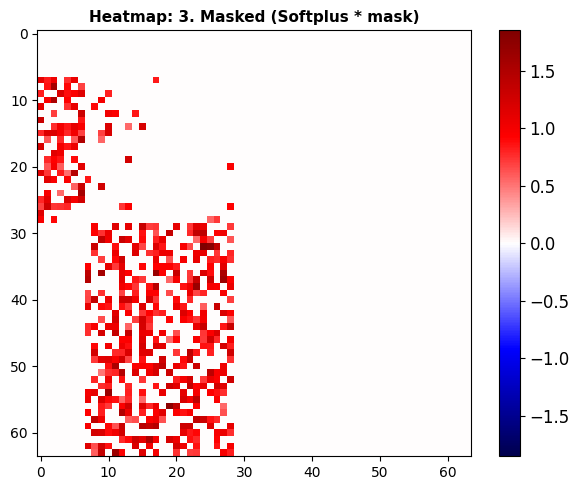

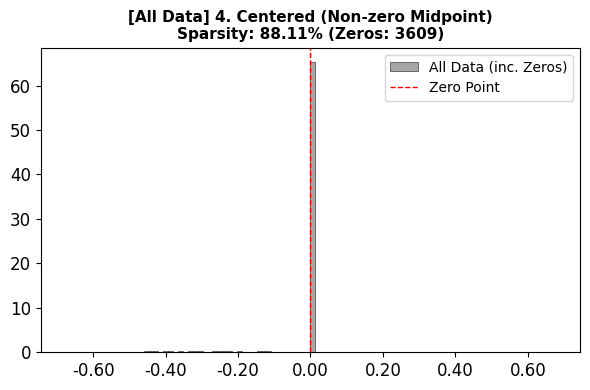

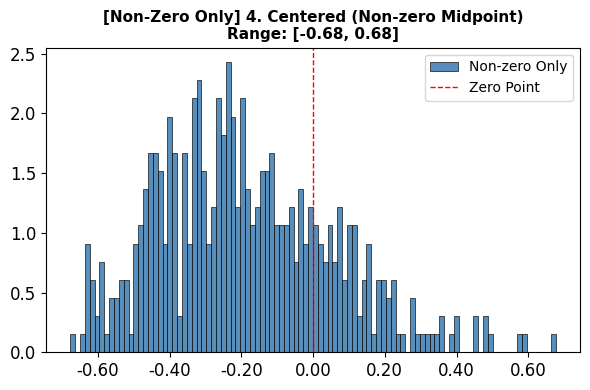

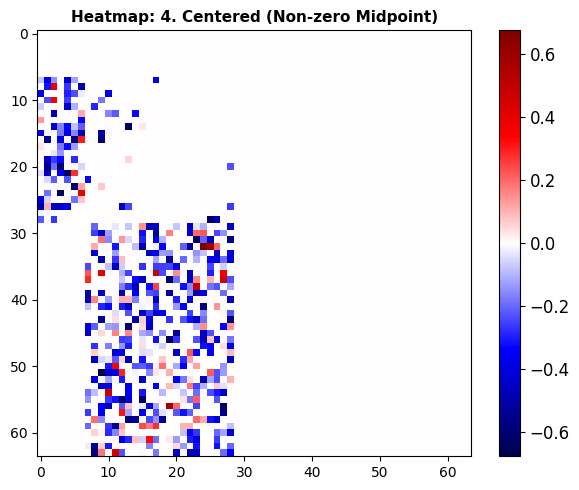

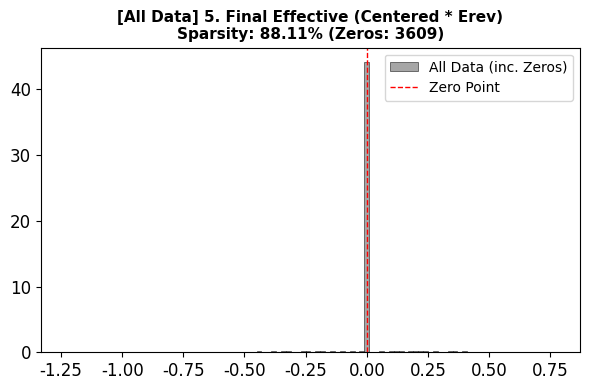

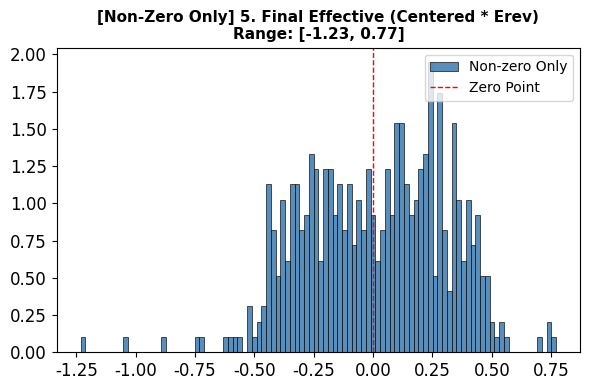

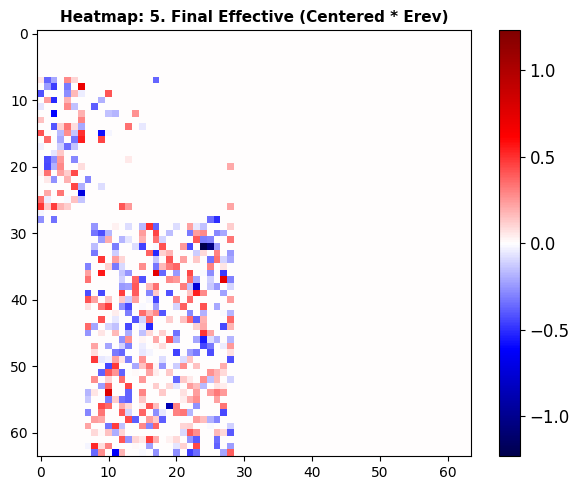

In [6]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import numpy as np
import torch.nn.functional as F

# ------------------------------------------------------------------
# ユーティリティ関数
# ------------------------------------------------------------------
def flatten_dict(d, prefix=""):
    flat = {}
    for k, v in d.items():
        name = f"{prefix}{k}"
        if isinstance(v, dict):
            flat.update(flatten_dict(v, prefix=name + "."))
        else:
            flat[name] = v
    return flat

def find_key_endswith(flat_dict, suffix):
    for k in flat_dict.keys():
        if k.endswith(suffix):
            return k
    return None

def shift_to_center_nonzero_midpoint(x):
    """
    【修正版: スパース性維持】
    1. 0以外の「非ゼロ要素」だけを取り出す
    2. その非ゼロ要素の Max と Min の中間 (Midpoint) を計算する
    3. 「非ゼロ要素からのみ」その値を引く（0の部分は0のまま触らない）
    """
    # 元のデータを書き換えないようにコピーを作成
    out = x.clone()
    
    # 非ゼロの場所（マスク）を作成
    mask = out != 0
    non_zeros = out[mask]
    
    if non_zeros.numel() == 0:
        return out # 非ゼロがなければそのまま返す
    
    # 最大値と最小値を取得
    max_val = torch.max(non_zeros)
    min_val = torch.min(non_zeros)
    
    # 中点 (Midpoint) を計算
    midpoint = (max_val + min_val) / 2.0
    
    print(f"  [Center Info] Non-zero Min: {min_val:.4f}, Max: {max_val:.4f}, Midpoint: {midpoint:.4f}")
    
    # 【重要】マスクされている部分（元々0じゃなかった部分）からのみ引く
    # これにより、元々0だった場所は計算対象外となり、0のまま維持されます
    out[mask] = non_zeros - midpoint
    
    return out

# ------------------------------------------------------------------
# プロット関数 (完全分割 + 2パターン表示)
# ------------------------------------------------------------------
def plot_separated_stages(
    checkpoint_path: str,
    bins: int = 100,
    tick_fontsize: int = 12,
):
    print(f"Loading model from {checkpoint_path} ...")
    state = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    
    flat = flatten_dict(state)
    
    # パラメータ取得
    w_key = find_key_endswith(flat, "rnn_cell.w")
    mask_key = find_key_endswith(flat, "rnn_cell.sparsity_mask")
    erev_key = find_key_endswith(flat, "rnn_cell.erev")
    
    if not (w_key and mask_key and erev_key):
        print("Error: 必要なパラメータが見つかりません。")
        return

    w_raw = flat[w_key]
    mask = flat[mask_key]
    erev = flat[erev_key]

    # ------------------------------------------------------------------
    # データ変換パイプライン
    # ------------------------------------------------------------------
    stages = []

    # 1. Raw (w)
    stages.append(("1. Raw Weights (w)", w_raw))

    # 2. Softplus Applied
    w_softplus = F.softplus(w_raw)
    stages.append(("2. Softplus (Positive)", w_softplus))

    # 3. Masked (Softplus * mask) -> ここで0が大量発生
    w_masked = w_softplus * mask
    stages.append(("3. Masked (Softplus * mask)", w_masked))

    # 4. Centered (Non-zero Midpoint)
    # 0以外の部分の中心を0に持ってくる。0はそのまま。
    w_centered = shift_to_center_nonzero_midpoint(w_masked)
    stages.append(("4. Centered (Non-zero Midpoint)", w_centered))

    # 5. Effective Rev (Centered * Erev)
    w_rev = w_centered * erev
    stages.append(("5. Final Effective (Centered * Erev)", w_rev))

    # ------------------------------------------------------------------
    # 描画ループ
    # ------------------------------------------------------------------
    for i, (name, data) in enumerate(stages):
        flat_data = data.detach().cpu().numpy().flatten()
        mat_data = data.detach().cpu().numpy()
        
        # 非ゼロデータの抽出
        nz_data = flat_data[flat_data != 0]
        
        # 統計情報
        total_count = flat_data.size
        zero_count = total_count - nz_data.size
        sparsity = (zero_count / total_count) * 100

        # ======================================================
        # パターン1: 0を含む全体ヒストグラム (Sparsity確認用)
        # ======================================================
        plt.figure(figsize=(6, 4))
        ax = plt.gca()
        
        ax.hist(
            flat_data,
            bins=bins,
            density=True,
            color="gray", # 全体はグレー
            edgecolor="black",
            linewidth=0.5,
            alpha=0.7,
            label="All Data (inc. Zeros)"
        )
        ax.axvline(0, color='red', linestyle='--', linewidth=1, label="Zero Point")
        
        title_str = f"[All Data] {name}\nSparsity: {sparsity:.2f}% (Zeros: {zero_count})"
        ax.set_title(title_str, fontsize=11, fontweight='bold')
        ax.tick_params(labelsize=tick_fontsize)
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

        # ======================================================
        # パターン2: 非ゼロのみヒストグラム (分布形状確認用)
        # ======================================================
        if len(nz_data) > 0:
            nz_min = nz_data.min()
            nz_max = nz_data.max()
            
            plt.figure(figsize=(6, 4))
            ax = plt.gca()
            
            ax.hist(
                nz_data,
                bins=bins,
                density=True,
                color="steelblue", # 有効データは青
                edgecolor="black",
                linewidth=0.5,
                alpha=0.9,
                label="Non-zero Only"
            )
            ax.axvline(0, color='red', linestyle='--', linewidth=1, label="Zero Point")
            
            title_str = f"[Non-Zero Only] {name}\nRange: [{nz_min:.2f}, {nz_max:.2f}]"
            ax.set_title(title_str, fontsize=11, fontweight='bold')
            ax.tick_params(labelsize=tick_fontsize)
            ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
            ax.legend(loc='upper right')
            plt.tight_layout()
            plt.show()
        else:
            print(f"  -> {name} has no non-zero elements. Skip Plot 2.")

        # ======================================================
        # ヒートマップ (全体像)
        # ======================================================
        plt.figure(figsize=(6, 5))
        ax = plt.gca()
        
        abs_max = np.abs(mat_data).max()
        if abs_max == 0: abs_max = 1.0

        im = ax.imshow(
            mat_data,
            cmap="seismic", 
            vmin=-abs_max,
            vmax=abs_max,
            aspect="auto",
            interpolation="nearest"
        )
        
        ax.set_title(f"Heatmap: {name}", fontsize=11, fontweight='bold')
        cbar = plt.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=tick_fontsize)
        plt.tight_layout()
        plt.show()

# ------------------------------------------------------------------
# 実行
# ------------------------------------------------------------------
path = "/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth"

plot_separated_stages(path)

Total keys found: 130


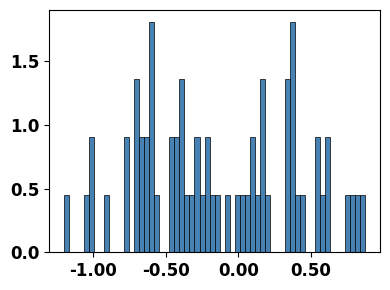

Sparsity mask or weights not found.
Total keys found: 130


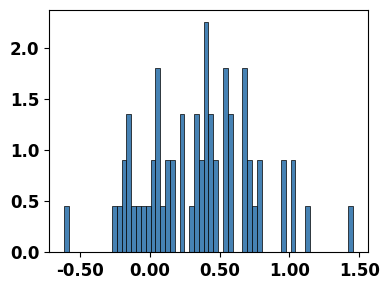

Sparsity mask or weights not found.
Total keys found: 130


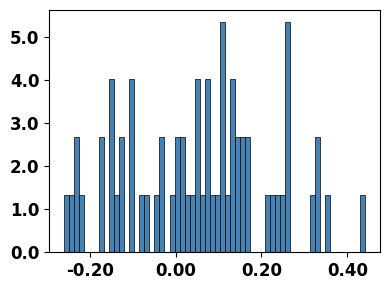

Sparsity mask or weights not found.


In [75]:
# Digital RRAM
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.cm"])
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.gleak"])
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.vleak"])

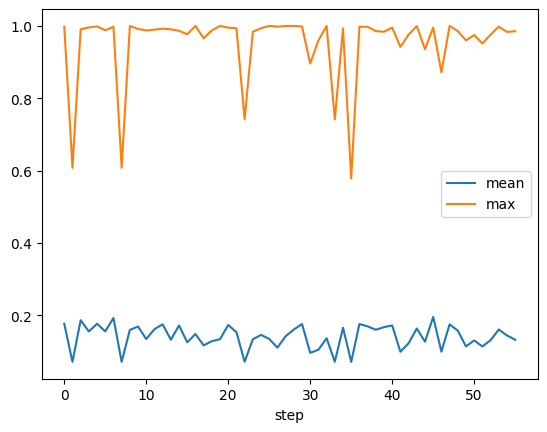

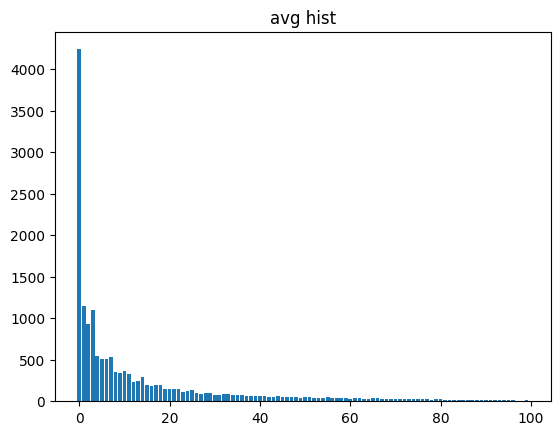

In [9]:
import json, numpy as np, matplotlib.pyplot as plt

with open("/work/robomimic/quantize_logs/CAM/uunit128_8bit.json") as f:
    data = json.load(f)

means = [d["activations"]["mean"] for d in data]
maxes = [d["activations"]["max"] for d in data]

plt.plot(means, label="mean")
plt.plot(maxes, label="max")
plt.xlabel("step"); plt.legend(); plt.show()

# ヒストを平均して全体傾向を見る
hist_avg = np.mean([np.array(d["activations"]["hist"]) for d in data], axis=0)
plt.bar(range(len(hist_avg)), hist_avg)
plt.title("avg hist"); plt.show()